# Book Recommender System
## LightGCN sur le Book Crossing Dataset

Projet 8INF974 — Système de recommandation de livres par Graph Neural Networks.

**Pipeline :**
1. Prétraitement & analyse du dataset
2. Split train/test au niveau des arêtes
3. Construction du graphe biparti user-livre
4. Modèle LightGCN
5. Loss BPR + métriques Recall@K / Precision@K
6. Entraînement et évaluation
7. Génération de recommandations

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import LGConv
from sklearn.model_selection import train_test_split
import sklearn.preprocessing as pp
import random
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")

C:\Users\MH030\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device : cpu


## 1. Prétraitement & analyse du dataset

In [2]:
ratings = pd.read_csv("../data/Book Crossing Dataset/BX-Book-Ratings.csv", sep=";", encoding="latin-1")
books   = pd.read_csv("../data/Book Crossing Dataset/BX-Books.csv", sep=";", encoding="latin-1",
                      on_bad_lines='skip', low_memory=False)

print(f"Ratings bruts  : {len(ratings):,}")
print(f"Livres uniques : {books['ISBN'].nunique():,}")
print(f"Users uniques  : {ratings['User-ID'].nunique():,}")

Ratings bruts  : 1,149,780
Livres uniques : 271,360
Users uniques  : 105,283


In [3]:
# Valeurs nulles
print("Nulls dans ratings :")
print(ratings.isnull().sum())
ratings.dropna(inplace=True)

Nulls dans ratings :
User-ID        0
ISBN           0
Book-Rating    0
dtype: int64


In [4]:
# Supprimer les notations implicites (rating == 0)
ratings = ratings[ratings["Book-Rating"] > 0]
print(f"Ratings explicites : {len(ratings):,}")

Ratings explicites : 433,671


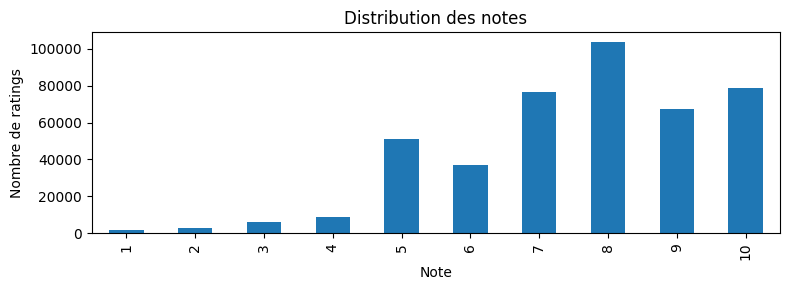

In [5]:
# ── Distribution des notes ───────────────────────────────────────────────────
ratings['Book-Rating'].value_counts().sort_index().plot(kind='bar', figsize=(8, 3),
    title='Distribution des notes', xlabel='Note', ylabel='Nombre de ratings')
plt.tight_layout()
plt.show()

In [6]:
# ── Corriger les ISBN invalides (non présents dans le catalogue livres) ──────
# BUG CORRIGÉ : on log le nombre d'ISBN manquants avant ET après filtrage
valid_isbn = set(books['ISBN'].unique())
missing_isbn = set(ratings['ISBN']) - valid_isbn
print(f"ISBN présents dans ratings mais absents du catalogue : {len(missing_isbn):,}")

ratings = ratings[ratings['ISBN'].isin(valid_isbn)].copy()
print(f"Ratings après filtrage ISBN : {len(ratings):,}")

ISBN présents dans ratings mais absents du catalogue : 36,137
Ratings après filtrage ISBN : 383,842


In [7]:
# ── Filtres de densité : utilisateurs et livres avec suffisamment d'interactions ──
MIN_USER_INTERACTIONS = 10
MIN_BOOK_RATINGS      = 10

# Filtre itératif (2 passes) pour s'assurer de la cohérence après chaque filtre
for _ in range(2):
    user_counts = ratings["User-ID"].value_counts()
    ratings = ratings[ratings["User-ID"].isin(
        user_counts[user_counts >= MIN_USER_INTERACTIONS].index)]

    book_counts = ratings["ISBN"].value_counts()
    ratings = ratings[ratings["ISBN"].isin(
        book_counts[book_counts >= MIN_BOOK_RATINGS].index)]

print(f"Users  après filtres : {ratings['User-ID'].nunique():,}")
print(f"Livres après filtres : {ratings['ISBN'].nunique():,}")
print(f"Ratings après filtres: {len(ratings):,}")

Users  après filtres : 2,217
Livres après filtres : 2,248
Ratings après filtres: 46,703


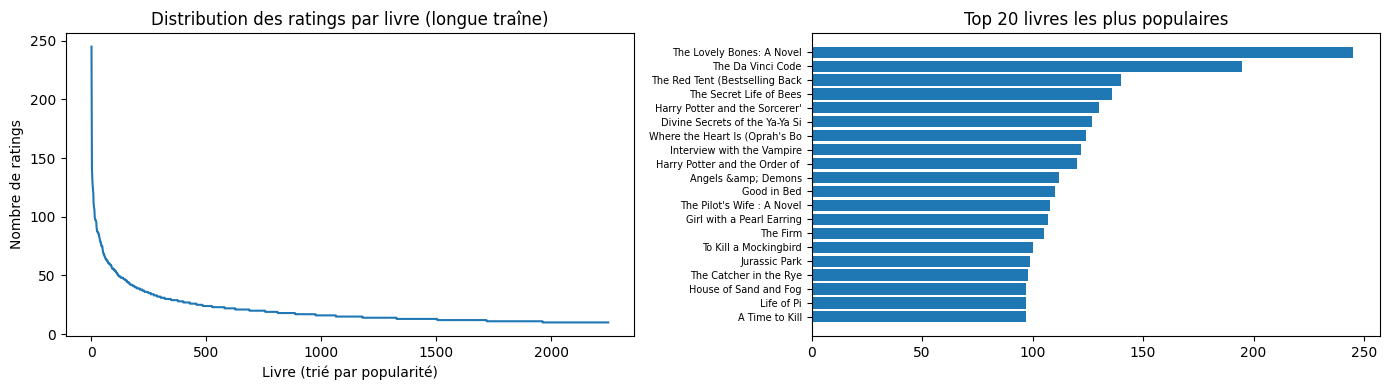

⚠ Le top 5% des livres concentre 18.5% des ratings (biais de popularité)


In [8]:
# ── Analyse du biais de popularité ──────────────────────────────────────────
# AMÉLIORATION : visualiser la longue traîne pour comprendre le biais
book_pop = ratings['ISBN'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(range(len(book_pop)), book_pop.values)
axes[0].set_title('Distribution des ratings par livre (longue traîne)')
axes[0].set_xlabel('Livre (trié par popularité)')
axes[0].set_ylabel('Nombre de ratings')

top_n = 20
top_books = book_pop.head(top_n)
top_titles = books.set_index('ISBN').loc[top_books.index, 'Book-Title'].values
axes[1].barh(range(top_n), top_books.values)
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels([t[:30] for t in top_titles], fontsize=7)
axes[1].set_title(f'Top {top_n} livres les plus populaires')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# % des ratings concentrés dans le top 5% des livres
top5_pct_books = int(len(book_pop) * 0.05)
top5_pct_ratings = book_pop.head(top5_pct_books).sum() / book_pop.sum()
print(f"⚠ Le top 5% des livres concentre {top5_pct_ratings:.1%} des ratings (biais de popularité)")

In [9]:
# ── Garder seulement les bonnes notes (>= 5) ────────────────────────────────
good_ratings = ratings[ratings['Book-Rating'] >= 5].copy()

print(f"Nœuds utilisateurs : {good_ratings['User-ID'].nunique():,}")
print(f"Nœuds livres       : {good_ratings['ISBN'].nunique():,}")
print(f"Arêtes (ratings)   : {len(good_ratings):,}")
print(f"Densité du graphe  : {len(good_ratings) / (good_ratings['User-ID'].nunique() * good_ratings['ISBN'].nunique()):.4%}")

Nœuds utilisateurs : 2,217
Nœuds livres       : 2,248
Arêtes (ratings)   : 45,261
Densité du graphe  : 0.9082%


## 2. Split Train / Test au niveau des arêtes

In [10]:
# Split 80/20
train_arr, test_arr = train_test_split(good_ratings.values, test_size=0.2, random_state=16)
train_df = pd.DataFrame(train_arr, columns=good_ratings.columns)
test_df  = pd.DataFrame(test_arr,  columns=good_ratings.columns)

print(f"Train : {len(train_df):,} | Test : {len(test_df):,}")

Train : 36,208 | Test : 9,053


In [11]:
# LabelEncoder : PyG a besoin d'indices continus de 0 à N
le_user = pp.LabelEncoder()
le_book = pp.LabelEncoder()

train_df['user_id_idx'] = le_user.fit_transform(train_df['User-ID'].values)
train_df['item_id_idx'] = le_book.fit_transform(train_df['ISBN'].values)

In [12]:
# Supprimer du test les users/livres absents du train
train_user_ids = set(train_df['User-ID'].unique())
train_book_ids = set(train_df['ISBN'].unique())

test_df = test_df[
    test_df['User-ID'].isin(train_user_ids) &
    test_df['ISBN'].isin(train_book_ids)
].copy()

# Encoder le test avec .transform (pas .fit_transform)
test_df['user_id_idx'] = le_user.transform(test_df['User-ID'].values)
test_df['item_id_idx'] = le_book.transform(test_df['ISBN'].values)

n_users = train_df['user_id_idx'].nunique()
n_items = train_df['item_id_idx'].nunique()
print(f"Users : {n_users:,} | Livres : {n_items:,}")

Users : 2,216 | Livres : 2,248


## 3. Graphe Biparti User-Livre (Edge Index)

In [13]:
# Graphe non orienté : chaque arête dans les 2 sens
# Les indices livres sont décalés de + n_users pour avoir des IDs uniques
# user nodes  : indices [0, n_users)
# book nodes  : indices [n_users, n_users + n_books)

u_t = torch.LongTensor(train_df.user_id_idx.values)
i_t = torch.LongTensor(train_df.item_id_idx.values) + n_users

train_edge_index = torch.stack([
    torch.cat([u_t, i_t]),   # sources
    torch.cat([i_t, u_t])    # destinations
]).to(device)

print(f"Edge index shape : {train_edge_index.shape}  [2, 2 × N_interactions]")

Edge index shape : torch.Size([2, 72416])  [2, 2 × N_interactions]


## 4. Modèle LightGCN

In [14]:
class LightGCN(nn.Module):
    """
    LightGCN : convolution légère sans transformation linéaire.
    Chaque couche LGConv agrège les voisins normalisés.
    L'embedding final est la moyenne de toutes les couches (recommandé par les auteurs).
    """
    def __init__(self, latent_dim: int, num_layers: int, num_users: int, num_items: int):
        super().__init__()
        self.num_users = num_users
        self.num_items = num_items
        self.num_layers = num_layers

        # Un seul embedding pour tous les nœuds (users + books)
        self.embedding = nn.Embedding(num_users + num_items, latent_dim)
        self.convs = nn.ModuleList(LGConv() for _ in range(num_layers))

        # Initialisation normale (meilleurs résultats selon le papier LightGCN)
        nn.init.normal_(self.embedding.weight, std=0.1)

    def forward(self, edge_index):
        emb0 = self.embedding.weight
        embs = [emb0]
        x = emb0
        for conv in self.convs:
            x = conv(x=x, edge_index=edge_index)
            embs.append(x)

        # Moyenne de toutes les couches
        out = torch.mean(torch.stack(embs, dim=0), dim=0)
        return emb0, out

    def encode_minibatch(self, users, pos_items, neg_items, edge_index):
        emb0, out = self(edge_index)
        return (
            out[users],
            out[pos_items],
            out[neg_items],
            emb0[users],
            emb0[pos_items],
            emb0[neg_items]
        )

## 5. DataLoader, BPR Loss et Métriques

In [15]:
def data_loader(data, batch_size, n_usr, n_itm):
    """
    Pour chaque batch :
    - users    : échantillon aléatoire d'utilisateurs
    - pos_items: 1 livre lu par user (interaction existante)
    - neg_items: 1 livre non lu par user (négatif aléatoire)

    BUG CORRIGÉ : gestion du cas où n_usr < batch_size
    """
    def sample_neg(x):
        while True:
            neg_id = random.randint(0, n_itm - 1)
            if neg_id not in x:
                return neg_id

    interacted_items_df = (
        data.groupby('user_id_idx')['item_id_idx']
            .apply(list)
            .reset_index()
    )
    indices = list(range(n_usr))

    if n_usr < batch_size:
        users = [random.choice(indices) for _ in range(batch_size)]
    else:
        users = random.sample(indices, batch_size)
    users.sort()

    users_df = pd.DataFrame(users, columns=['users'])
    interacted_items_df = pd.merge(
        interacted_items_df, users_df,
        how='right', left_on='user_id_idx', right_on='users'
    )

    pos_items = interacted_items_df['item_id_idx'].apply(lambda x: random.choice(x)).values
    neg_items = interacted_items_df['item_id_idx'].apply(lambda x: sample_neg(x)).values

    return (
        torch.LongTensor(users).to(device),
        torch.LongTensor(pos_items).to(device) + n_usr,
        torch.LongTensor(neg_items).to(device) + n_usr
    )

In [16]:
def compute_bpr_loss(users, users_emb, pos_emb, neg_emb, user_emb0, pos_emb0, neg_emb0):
    """
    BPR Loss : on veut que le score de l'item positif > négatif.
    Régularisation L2 sur les embeddings initiaux pour éviter l'overfitting.
    """
    reg_loss = (1 / 2) * (
        user_emb0.norm().pow(2) +
        pos_emb0.norm().pow(2)  +
        neg_emb0.norm().pow(2)
    ) / float(len(users))

    pos_scores = torch.mul(users_emb, pos_emb).sum(dim=1)
    neg_scores = torch.mul(users_emb, neg_emb).sum(dim=1)
    bpr_loss   = torch.mean(F.softplus(neg_scores - pos_scores))

    return bpr_loss, reg_loss

In [17]:
def get_metrics(user_emb, item_emb, n_users, n_items, train_data, test_data, K):
    """
    Calcule Recall@K et Precision@K.

    BUG CORRIGÉ 1 : utilisait train_df global au lieu du paramètre train_data
    BUG CORRIGÉ 2 : cast float32 pour cohérence avec les embeddings du modèle
    """
    # Score de toutes les paires user-item
    relevance_score = torch.matmul(user_emb, item_emb.T)  # (n_users, n_items)

    # Masque des interactions d'entraînement (déjà vues → ne pas recommander)
    i = torch.stack([
        torch.LongTensor(train_data['user_id_idx'].values),
        torch.LongTensor(train_data['item_id_idx'].values)
    ])
    v = torch.ones(len(train_data), dtype=torch.float32)  # BUG CORRIGÉ : float32
    interactions_t = (
        torch.sparse_coo_tensor(i, v, (n_users, n_items))
            .to_dense()
            .to(device)
    )
    relevance_score = relevance_score * (1 - interactions_t)

    # Top-K items par utilisateur
    topk_indices = torch.topk(relevance_score, K).indices  # (n_users, K)
    topk_df = pd.DataFrame(
        topk_indices.cpu().numpy(),
        columns=[f'top_{k+1}' for k in range(K)]
    )
    topk_df['user_ID']       = topk_df.index
    topk_df['top_rlvnt_itm'] = topk_df[[f'top_{k+1}' for k in range(K)]].values.tolist()
    topk_df = topk_df[['user_ID', 'top_rlvnt_itm']]

    # Chevauchement avec les vrais items du test
    test_interacted = (
        test_data.groupby('user_id_idx')['item_id_idx']
                 .apply(list)
                 .reset_index()
    )
    metrics_df = pd.merge(
        test_interacted, topk_df,
        how='left', left_on='user_id_idx', right_on='user_ID'
    )
    metrics_df['intrsctn_itm'] = [
        list(set(a).intersection(b))
        for a, b in zip(metrics_df.item_id_idx, metrics_df.top_rlvnt_itm)
    ]
    metrics_df['recall']    = metrics_df.apply(
        lambda x: len(x['intrsctn_itm']) / max(len(x['item_id_idx']), 1), axis=1)  # division safe
    metrics_df['precision'] = metrics_df.apply(
        lambda x: len(x['intrsctn_itm']) / K, axis=1)

    return metrics_df['recall'].mean(), metrics_df['precision'].mean()

## 6. Entraînement & Évaluation

In [18]:
# Hyperparamètres
LATENT_DIM = 64
N_LAYERS   = 3
EPOCHS     = 50
BATCH_SIZE = 1024
DECAY      = 1e-4
LR         = 5e-3
K          = 20

In [19]:
def train_and_eval(model, optimizer, train_df, test_df):
    """
    Boucle d'entraînement LightGCN.

    BUG CORRIGÉ : n_batch utilisait len(train) (numpy array du split initial)
                  → corrigé en len(train_df) pour rester cohérent.
    """
    loss_list_epoch     = []
    bpr_loss_list_epoch = []
    reg_loss_list_epoch = []
    recall_list         = []
    precision_list      = []

    for epoch in tqdm(range(EPOCHS), desc='Training'):
        # BUG CORRIGÉ : len(train_df) au lieu de len(train)
        n_batch = max(1, int(len(train_df) / BATCH_SIZE))

        final_loss_list = []
        bpr_loss_list   = []
        reg_loss_list   = []

        model.train()
        for _ in range(n_batch):
            optimizer.zero_grad()

            users, pos_items, neg_items = data_loader(train_df, BATCH_SIZE, n_users, n_items)
            users_emb, pos_emb, neg_emb, userEmb0, posEmb0, negEmb0 = \
                model.encode_minibatch(users, pos_items, neg_items, train_edge_index)

            bpr_loss, reg_loss = compute_bpr_loss(
                users, users_emb, pos_emb, neg_emb, userEmb0, posEmb0, negEmb0
            )
            final_loss = bpr_loss + DECAY * reg_loss

            final_loss.backward()
            optimizer.step()

            final_loss_list.append(final_loss.item())
            bpr_loss_list.append(bpr_loss.item())
            reg_loss_list.append(reg_loss.item())

        model.eval()
        with torch.no_grad():
            _, out = model(train_edge_index)
            user_emb, item_emb = torch.split(out, (n_users, n_items))
            recall, precision = get_metrics(
                user_emb, item_emb, n_users, n_items, train_df, test_df, K
            )

        loss_list_epoch.append(round(np.mean(final_loss_list), 4))
        bpr_loss_list_epoch.append(round(np.mean(bpr_loss_list), 4))
        reg_loss_list_epoch.append(round(np.mean(reg_loss_list), 4))
        recall_list.append(round(recall, 4))
        precision_list.append(round(precision, 4))

    return loss_list_epoch, bpr_loss_list_epoch, reg_loss_list_epoch, recall_list, precision_list

In [20]:
# Instanciation et entraînement
lightgcn = LightGCN(
    latent_dim=LATENT_DIM,
    num_layers=N_LAYERS,
    num_users=n_users,
    num_items=n_items
).to(device)

optimizer = torch.optim.Adam(lightgcn.parameters(), lr=LR)
print("Taille des embeddings apprenables :", [x.shape for x in lightgcn.parameters()])

Taille des embeddings apprenables : [torch.Size([4464, 64])]


In [21]:
losses, bpr, reg, recalls, precisions = train_and_eval(lightgcn, optimizer, train_df, test_df)

Training: 100%|██████████| 50/50 [02:02<00:00,  2.45s/it]


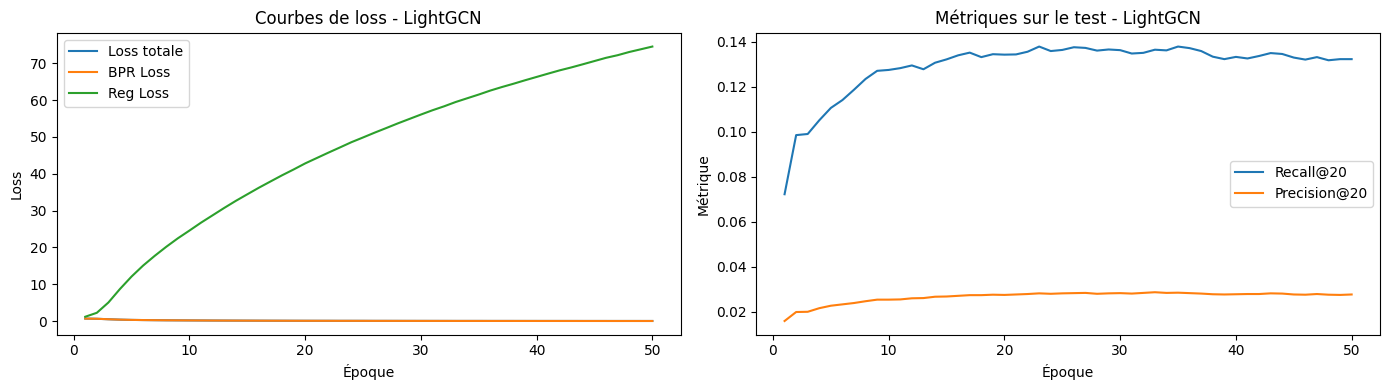

Meilleur Recall@20    : 0.1379
Meilleure Precision@20: 0.0286


In [22]:
# Courbes de loss
epoch_list = list(range(1, EPOCHS + 1))
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(epoch_list, losses,  label='Loss totale')
axes[0].plot(epoch_list, bpr,     label='BPR Loss')
axes[0].plot(epoch_list, reg,     label='Reg Loss')
axes[0].set_xlabel('Époque')
axes[0].set_ylabel('Loss')
axes[0].set_title('Courbes de loss - LightGCN')
axes[0].legend()

axes[1].plot(epoch_list, recalls,    label=f'Recall@{K}')
axes[1].plot(epoch_list, precisions, label=f'Precision@{K}')
axes[1].set_xlabel('Époque')
axes[1].set_ylabel('Métrique')
axes[1].set_title(f'Métriques sur le test - LightGCN')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Meilleur Recall@{K}    : {max(recalls):.4f}")
print(f"Meilleure Precision@{K}: {max(precisions):.4f}")

## 7. Génération de Recommandations

In [23]:
def recommend_books(user_raw_id, model, train_edge_index, train_df, test_df,
                    books_df, n_users, n_items, K=10):
    """
    Recommande K livres à un utilisateur et évalue la qualité des recommandations
    en les comparant aux livres réellement lus dans le test_df.

    Paramètres
    ----------
    user_raw_id : int/str — User-ID original (avant encodage)
    test_df     : DataFrame — interactions de test, sert à évaluer les recommandations
    books_df    : DataFrame — catalogue avec ISBN, Book-Title, Book-Author

    Retourne
    --------
    DataFrame avec les K recommandations, une colonne 'hit' indiquant si
    le livre était bien dans le test de cet utilisateur.
    """
    if user_raw_id not in le_user.classes_:
        print(f"User {user_raw_id} inconnu du modèle.")
        return pd.DataFrame()

    model.eval()
    with torch.no_grad():
        _, out = model(train_edge_index)
        user_emb, item_emb = torch.split(out, (n_users, n_items))

    user_idx = le_user.transform([user_raw_id])[0]
    scores   = torch.matmul(user_emb[user_idx], item_emb.T).cpu().numpy()  # (n_items,)

    # Masquer les livres déjà lus dans le train (on ne les recommande pas)
    train_read_idx = set(train_df[train_df['user_id_idx'] == user_idx]['item_id_idx'].values)
    for idx in train_read_idx:
        scores[idx] = -np.inf

    # Livres du test pour cet utilisateur = la "vérité terrain"
    test_read_idx = set(test_df[test_df['user_id_idx'] == user_idx]['item_id_idx'].values)

    # Top-K recommandations
    top_k_idx  = np.argsort(scores)[::-1][:K]
    top_k_isbn = le_book.inverse_transform(top_k_idx)

    result = books_df[books_df['ISBN'].isin(top_k_isbn)][['ISBN', 'Book-Title', 'Book-Author']].copy()
    isbn_order = {isbn: rank for rank, isbn in enumerate(top_k_isbn)}
    result['rank'] = result['ISBN'].map(isbn_order)
    result = result.sort_values('rank').drop(columns='rank').reset_index(drop=True)

    # Colonne hit : True si le livre recommandé était dans le test de cet user
    rec_idx_map = {isbn: idx for idx, isbn in zip(top_k_idx, top_k_isbn)}
    result['hit ✅'] = result['ISBN'].map(
        lambda isbn: rec_idx_map.get(isbn) in test_read_idx
    )

    # Résumé de performance pour cet utilisateur
    n_hits = result['hit ✅'].sum()
    precision_u = n_hits / K
    recall_u    = n_hits / max(len(test_read_idx), 1)
    print(f"User {user_raw_id} — Livres dans le test : {len(test_read_idx)} "
          f"| Hits : {n_hits}/{K} "
          f"| Precision@{K} : {precision_u:.2f} "
          f"| Recall@{K} : {recall_u:.2f}")

    result.index += 1  # affichage 1-based
    return result


def show_already_read(user_raw_id, df, books_df, label=''):
    """Affiche les livres lus par un utilisateur dans un split donné."""
    user_idx  = le_user.transform([user_raw_id])[0]
    read_idx  = df[df['user_id_idx'] == user_idx]['item_id_idx'].values
    isbn_list = le_book.inverse_transform(read_idx)
    result = books_df[books_df['ISBN'].isin(isbn_list)][['ISBN', 'Book-Title', 'Book-Author']].reset_index(drop=True)
    print(f"Livres lus ({label}) — User {user_raw_id} : {len(result)} livres")
    return result

In [27]:
# Exemple : choisir un utilisateur présent dans le train ET dans le test
example_user = test_df['User-ID'].iloc[0]  # garanti d'être dans les deux splits
print(f"Utilisateur exemple : {example_user}")

print("\n--- Livres lus dans le TRAIN (connus du modèle) ---")
display(show_already_read(example_user, train_df, books, label='train'))

print("\n--- Livres lus dans le TEST (vérité terrain cachée) ---")
display(show_already_read(example_user, test_df, books, label='test'))

print("\n--- Recommandations LightGCN (avec évaluation vs test) ---")
display(recommend_books(
    user_raw_id=example_user,
    model=lightgcn,
    train_edge_index=train_edge_index,
    train_df=train_df,
    test_df=test_df,
    books_df=books,
    n_users=n_users,
    n_items=n_items,
    K=10
))

Utilisateur exemple : 112001

--- Livres lus dans le TRAIN (connus du modèle) ---
Livres lus (train) — User 112001 : 55 livres


,ISBN,Book-Title,Book-Author
0,0440225701,The Street Lawyer,JOHN GRISHAM
1,0679429220,Midnight in the Garden of Good and Evil: A Sav...,John Berendt
2,1558744150,Chicken Soup for the Woman's Soul (Chicken Sou...,Jack Canfield
3,0449207544,Proof,Dick Francis
4,0316666343,The Lovely Bones: A Novel,Alice Sebold
5,0375726403,Empire Falls,Richard Russo
6,0515127833,River's End,Nora Roberts
7,0440122090,Echoes,Maeve Binchy
8,0446531332,Nights in Rodanthe,Nicholas Sparks
9,0451205421,The Door to December,Dean R. Koontz



--- Livres lus dans le TEST (vérité terrain cachée) ---
Livres lus (test) — User 112001 : 17 livres


,ISBN,Book-Title,Book-Author
0,0786868716,The Five People You Meet in Heaven,Mitch Albom
1,0385508042,The King of Torts,John Grisham
2,044023722X,A Painted House,John Grisham
3,0553272837,Brazen Virtue,Nora Roberts
4,0345313860,"The Vampire Lestat (Vampire Chronicles, Book II)",ANNE RICE
5,0446523569,Message in a Bottle,Nicholas Sparks
6,0671003755,She's Come Undone (Oprah's Book Club (Paperback)),Wally Lamb
7,0553579754,Fear Nothing,DEAN KOONTZ
8,0425181103,Phantoms,Dean R. Koontz
9,0061042005,Suddenly,Barbara Delinsky



--- Recommandations LightGCN (avec évaluation vs test) ---
User 112001 — Livres dans le test : 17 | Hits : 1/10 | Precision@10 : 0.10 | Recall@10 : 0.06


,ISBN,Book-Title,Book-Author,hit ✅
1,0440226430,Summer Sisters,Judy Blume,False
2,0446611867,A Bend in the Road,Nicholas Sparks,False
3,0316601950,The Pilot's Wife : A Novel,Anita Shreve,False
4,0671021001,She's Come Undone (Oprah's Book Club),Wally Lamb,False
5,044023722X,A Painted House,John Grisham,True
6,0316899984,"River, Cross My Heart",Breena Clarke,False
7,0440204194,Firefly Summer,Maeve Binchy,False
8,0515131229,Dance upon the Air (Three Sisters Island Trilogy),Nora Roberts,False
9,0515128554,Heart of the Sea (Irish Trilogy),Nora Roberts,False
10,0446672211,Where the Heart Is (Oprah's Book Club (Paperba...,Billie Letts,False


## 8. Analyse comparative — Baseline aléatoire

Pour valider que le modèle fait mieux que le hasard.

In [25]:
def random_baseline_metrics(train_data, test_data, n_items, K, n_samples=200):
    """
    Calcule Recall@K et Precision@K d'une baseline aléatoire.
    Pour chaque user, on recommande K livres au hasard (hors train).
    """
    test_grouped = test_data.groupby('user_id_idx')['item_id_idx'].apply(set).to_dict()
    train_grouped = train_data.groupby('user_id_idx')['item_id_idx'].apply(set).to_dict()

    recalls, precisions = [], []
    for user_idx, true_items in list(test_grouped.items())[:n_samples]:
        seen = train_grouped.get(user_idx, set())
        candidates = list(set(range(n_items)) - seen)
        recs = set(random.sample(candidates, min(K, len(candidates))))
        hits = len(recs & true_items)
        recalls.append(hits / max(len(true_items), 1))
        precisions.append(hits / K)

    return np.mean(recalls), np.mean(precisions)


rand_recall, rand_precision = random_baseline_metrics(train_df, test_df, n_items, K)
print(f"Baseline aléatoire — Recall@{K}: {rand_recall:.4f} | Precision@{K}: {rand_precision:.4f}")
print(f"LightGCN          — Recall@{K}: {max(recalls):.4f} | Precision@{K}: {max(precisions):.4f}")
print(f"\nGain Recall    : ×{max(recalls)/max(rand_recall, 1e-6):.1f}")
print(f"Gain Precision : ×{max(precisions)/max(rand_precision, 1e-6):.1f}")

Baseline aléatoire — Recall@20: 0.0123 | Precision@20: 0.0030
LightGCN          — Recall@20: 0.1379 | Precision@20: 0.0286

Gain Recall    : ×11.2
Gain Precision : ×9.5
